In [1]:
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
from jax import jit, grad, jacobian, vmap, lax
import jax.numpy as jnp

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import scipy.linalg as sl

In [5]:
mol = 'heh+'
basis = '6-31g'
method = 'fci'

In [6]:
dt = 0.01
T = 200.0
numsteps = int(np.ceil(T/dt))
print("numsteps = " + str(numsteps))

# field parameters: 
freq = 0.1  # frequency
amp = 0.5   # amplitude
ncyc = 5.0  # number of cycles to keep field on

# Let us take the field to be
# amp * sin(2 * pi * freq * t) so that the period is T = 1 / freq.
# Thus we will keep the field on for ncyc * T = ncyc / freq a.u.,
# which translates into ncyc / (dt * freq) time steps.

stepoff = int(np.ceil(ncyc / (dt * freq)))
print("field will be on for " + str(stepoff) + " time steps")

numsteps = 20000
field will be on for 5000 time steps


In [7]:
fname = method + '_' + mol + '_' + basis + '.npz'
print(fname)

fci_heh+_6-31g.npz


In [8]:
prefix = './psi4data/'
psi4data = np.load(prefix + fname)

In [9]:
print(list(psi4data.keys()))

['C', 'S', 'AOdipmat', 'CIdimatz', 'Bten', 'ham']


In [10]:
drcCI = psi4data['Bten'].shape[0]
drc = psi4data['Bten'].shape[2]

In [11]:
# propagate starting with a particular initial condition ic
statesCI = np.zeros((drcCI, numsteps+1), dtype=np.complex128)
statesCI[0,0] = 1.0
cnt = 0

# store the propagators, but only when the field is on; otherwise they are trivial
fieldprop = np.zeros((drcCI, drcCI, stepoff), dtype=np.complex128)

# propagate solution forward in time
for j in range(numsteps):
    h = np.diag(psi4data['ham'])
    if (j < stepoff):
        field = amp * np.sin(2*np.pi*freq*j*dt)
        print("Time step j = " + str(j) + "; field strength = " + str(field)) 
        h += field * psi4data['CIdimatz']
        dd, vv = np.linalg.eigh(h)
        prop = vv @ np.diag(np.exp(-1j * dt * dd)) @ vv.conj().T
        # print(np.linalg.norm(sl.expm(-1j*dt*h) - prop))
        fieldprop[:, :, j] = prop
    else:
        prop = np.diag(np.exp(-1j * dt * psi4data['ham']))
    
    statesCI[:,j+1] = prop @ statesCI[:,j]

Time step j = 0; field strength = 0.0
Time step j = 1; field strength = 0.0031415719827794755
Time step j = 2; field strength = 0.006283019941676304
Time step j = 3; field strength = 0.009424219857704088
Time step j = 4; field strength = 0.01256504772166874
Time step j = 5; field strength = 0.015705379539064146
Time step j = 6; field strength = 0.01884509133496727
Time step j = 7; field strength = 0.02198405915893245
Time step j = 8; field strength = 0.025122159089884778
Time step j = 9; field strength = 0.028259267241012263
Time step j = 10; field strength = 0.03139525976465669
Time step j = 11; field strength = 0.0345300128572029
Time step j = 12; field strength = 0.03766340276396636
Time step j = 13; field strength = 0.04079530578407877
Time step j = 14; field strength = 0.04392559827537158
Time step j = 15; field strength = 0.04705415665925716
Time step j = 16; field strength = 0.05018085742560745
Time step j = 17; field strength = 0.053305577137629956
Time step j = 18; field stren

In [12]:
# compute and store all 1-RDMs
Bmat = psi4data['Bten'].reshape((drcCI**2, drc**2))
BmatT = Bmat.T
truerdms = np.zeros((drc, drc, numsteps+1), dtype=np.complex128)
for j in range(numsteps+1):
    a = statesCI[:, [j]]
    trueden = a @ a.conj().T
    truerdms[:, :, j] = (BmatT @ trueden.reshape((-1))).reshape((drc, drc))

In [13]:
# check at once whether all 1-RDM traces are close to 2
print( np.mean(np.abs(np.einsum('aaj->j',truerdms) - 2)) )

2.820966198569471e-13


In [14]:
# BmatT has drcCI**2 columns
# let us figure out which of these columns are actually non-trivial
colnorms = np.array( list( map( lambda j : np.linalg.norm(BmatT[:,j]), np.arange(drcCI**2, dtype=np.int16) ) ) )
goodcols = np.where(colnorms > 1e-14)[0]
badcols = np.where(colnorms <= 1e-14)[0]
diagcols = np.where(np.eye(drcCI).reshape((-1)))[0]
fincols = goodcols[~np.isin(goodcols, diagcols)]
print(fincols)

[  2   4   6   7   9  11  12  14  15  19  21  24  26  29  32  36  38  39
  41  43  44  46  47  49  53  56  58  61  64  66  70  71  73  75  76  78
  79  81  83  88  90  93  96  98 100 103 105 107 108 110 111 112 114 116
 118 121 123 124 126 127 129 131 133 138 141 144 146 148 150 151 155 156
 158 159 161 163 165 168 173 176 178 180 182 183 185 188 190 191 192 194
 196 198 199 201 203 206 207 209 211 213 216 218 224 226 228 230 231 233
 235 236 239 240 242 244 246 247 249 251 252 254]


In [15]:
print(badcols)

[  1   3   5   8  10  13  16  18  20  22  23  25  27  28  30  31  33  35
  37  40  42  45  48  50  52  54  55  57  59  60  62  63  65  67  69  72
  74  77  80  82  84  86  87  89  91  92  94  95  97  99 101 104 106 109
 113 115 117 120 122 125 128 130 132 134 135 137 139 140 142 143 145 147
 149 152 154 157 160 162 164 166 167 169 171 172 174 175 177 179 181 184
 186 189 193 195 197 200 202 205 208 210 212 214 215 217 219 220 222 223
 225 227 229 232 234 237 241 243 245 248 250 253]


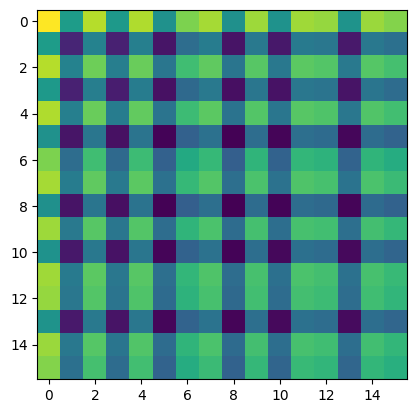

In [16]:
j = 2
a = statesCI[:, [j]]
trueden = a @ a.conj().T
plt.imshow(np.log(np.abs(trueden))/np.log(10.0))
plt.show()

In [17]:
zerostates = []
for j in range(drcCI):
    if np.linalg.norm(statesCI[j,:]) < 1e-10:
        zerostates.append(j)

In [18]:
print(zerostates)

[1, 3, 5, 8, 10, 13]


In [19]:
truedens = np.einsum('in,jn->ijn',statesCI,statesCI.conj())

In [20]:
truedenflat = truedens.reshape((drcCI**2, numsteps+1))

In [21]:
# plt.plot(np.abs(truedenflat[badcols,:]))
# plt.show()

In [22]:
err = np.zeros(stepoff)
err2 = np.zeros(stepoff)
norms = np.zeros(stepoff)

for j in range(stepoff):
    # true state vector at time step j
    a = statesCI[:, [j]]
    # true full density matrix at time step j
    trueden = a @ a.conj().T
    # turning this full density matrix into a vector
    truedenflat = trueden.reshape((-1))
    # print out the norm of the entries corresponding to "badcols"
    norms[j] = np.linalg.norm(truedenflat[badcols])
    # set entries to zero
    truedenflat[badcols] = 0
    # make this into a matrix again
    trueden = truedenflat.reshape((drcCI, drcCI))

    # true full density matrix at time step j+1
    aprime = statesCI[:, [j+1]]
    truedenprime = aprime @ aprime.conj().T
    
    err[j] = np.linalg.norm(truedenprime - fieldprop[:,:,j] @ trueden @ fieldprop[:,:,j].conj())
    bigprop = np.kron(fieldprop[:,:,j], fieldprop[:,:,j].conj())
    testprime = ((bigprop) @ trueden.reshape((-1))).reshape((drcCI, drcCI))
    err2[j] = np.linalg.norm(truedenprime - testprime)


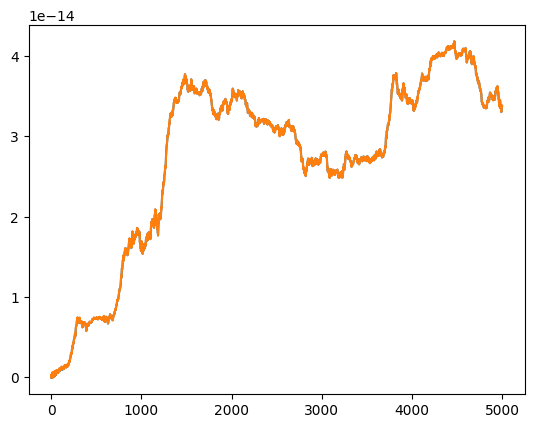

In [23]:
plt.plot(err)
plt.plot(err2)
plt.show()

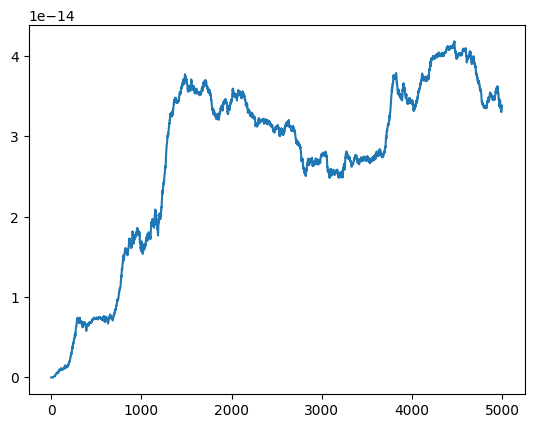

In [24]:
plt.plot(norms)
plt.show()

In [25]:
list(psi4data.keys())

['C', 'S', 'AOdipmat', 'CIdimatz', 'Bten', 'ham']

In [26]:
inv = np.zeros((drcCI,drcCI), dtype=np.int16)
fwd = {}
err = 0.0
for k in badcols:
    inv[k // 16, k % 16] = k
    fwd[k] = np.array([k // 16, k % 16])
    err += np.abs( psi4data['CIdimatz'][k // 16, k % 16] )

print(err)

9.453235469815212e-14


In [27]:
for j in range(len(badcols)):
    print(fwd[badcols[j]])

[0 1]
[0 3]
[0 5]
[0 8]
[ 0 10]
[ 0 13]
[1 0]
[1 2]
[1 4]
[1 6]
[1 7]
[1 9]
[ 1 11]
[ 1 12]
[ 1 14]
[ 1 15]
[2 1]
[2 3]
[2 5]
[2 8]
[ 2 10]
[ 2 13]
[3 0]
[3 2]
[3 4]
[3 6]
[3 7]
[3 9]
[ 3 11]
[ 3 12]
[ 3 14]
[ 3 15]
[4 1]
[4 3]
[4 5]
[4 8]
[ 4 10]
[ 4 13]
[5 0]
[5 2]
[5 4]
[5 6]
[5 7]
[5 9]
[ 5 11]
[ 5 12]
[ 5 14]
[ 5 15]
[6 1]
[6 3]
[6 5]
[6 8]
[ 6 10]
[ 6 13]
[7 1]
[7 3]
[7 5]
[7 8]
[ 7 10]
[ 7 13]
[8 0]
[8 2]
[8 4]
[8 6]
[8 7]
[8 9]
[ 8 11]
[ 8 12]
[ 8 14]
[ 8 15]
[9 1]
[9 3]
[9 5]
[9 8]
[ 9 10]
[ 9 13]
[10  0]
[10  2]
[10  4]
[10  6]
[10  7]
[10  9]
[10 11]
[10 12]
[10 14]
[10 15]
[11  1]
[11  3]
[11  5]
[11  8]
[11 10]
[11 13]
[12  1]
[12  3]
[12  5]
[12  8]
[12 10]
[12 13]
[13  0]
[13  2]
[13  4]
[13  6]
[13  7]
[13  9]
[13 11]
[13 12]
[13 14]
[13 15]
[14  1]
[14  3]
[14  5]
[14  8]
[14 10]
[14 13]
[15  1]
[15  3]
[15  5]
[15  8]
[15 10]
[15 13]


In [28]:
fwd[badcols[1]]
V = 0
W = 3

In [29]:
fieldprop[I,V,250] * fieldprop[W,J,250].conj()

NameError: name 'I' is not defined

In [ ]:
plt.imshow(np.log(np.abs(trueden)+1e-12)/np.log(10.0))
plt.show()
plt.imshow(np.log(np.abs(truedenprime)+1e-12)/np.log(10.0))
plt.show()

In [ ]:
plt.plot(err)
plt.plot(err2)
plt.show()

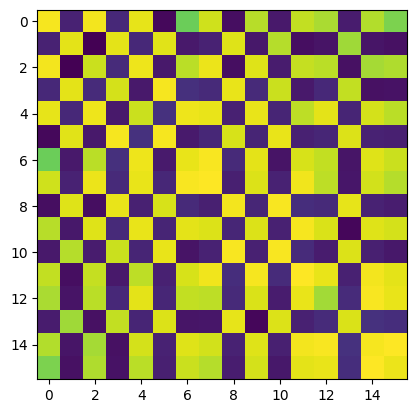

In [30]:
plt.imshow(np.log(np.abs(psi4data['CIdimatz']))/np.log(10.0))
plt.show()

In [39]:
zerostates

[1, 3, 5, 8, 10, 13]

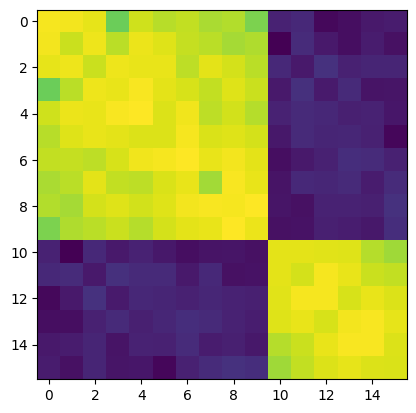

In [40]:
nzstates = [0,2,4,6,7,9,11,12,14,15]
neworder = nzstates + zerostates
dimat = psi4data['CIdimatz'][neworder,:][:,neworder]
plt.imshow(np.log(np.abs(dimat))/np.log(10.0))
plt.show()

In [ ]:
plt.imshow(np.log(np.abs(fieldprop[:,:,250]))/np.log(10.0))
plt.show()

In [ ]:
plt.imshow(np.log(np.abs(statesCI[:,[250]]))/np.log(10.0))
plt.show()

In [ ]:
testflat = np.ones((drcCI**2))
testflat[badcols] = 0.0
test = testflat.reshape((drcCI, drcCI))
plt.imshow(test)
plt.show()

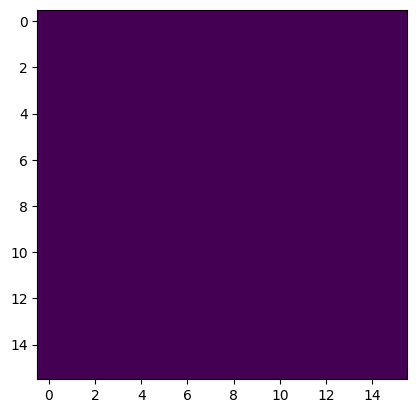

In [50]:
test2 = np.ones((drcCI, drcCI))
for i in range(drcCI):
    for j in range(drcCI):
        if i in zerostates:
            test2[i,j] = 0.0
        if j in zerostates:
            test2[i,j] = 0.0
plt.imshow(test2)
plt.show()

In [156]:
np.linalg.matrix_rank(BmatT)

np.int64(16)

In [ ]:
J = 2500
ell = 2000
Cmat = np.eye(drcCI, drcCI)
BtildeT = np.copy(BmatT)
for j in diagcols[1:]:
    BtildeT[:,j] -= BmatT[:,0]
BtildeT = BtildeT[:,goodcols]
BtildeT = BtildeT[:,1:]

bigmat = np.copy(BtildeT)
corr = [ BmatT[:,0] ]

for j in range(1, ell+1):
    Cmat = Cmat @ fieldprop[:,:,J - j].conj().T
    Amat = Cmat.conj().T
    bigprop = np.kron( Cmat.T, Amat )
    thisblock = BmatT @ bigprop
    thisblocktilde = np.copy(thisblock)
    for j in diagcols[1:]:
        thisblocktilde[:,j] -= thisblocktilde[:,0]
    thisblocktilde = thisblocktilde[:,goodcols]
    thisblocktilde = thisblocktilde[:,1:]
    corr.append( thisblock[:,0] )
    bigmat = np.concatenate([bigmat, thisblocktilde], axis=0)

a = statesCI[:, [J]]
trueden = a @ a.conj().T
truedentilde = trueden.reshape((-1))[goodcols]
trueq = bigmat @ truedentilde[1:]
err = 0
for j in range(ell+1):
    si = j*drc**2
    ei = (j+1)*drc**2
    err += np.linalg.norm( truerdms[:,:,J-j].reshape((-1)) - trueq[si:ei] - corr[j])

print(err)
print(np.linalg.matrix_rank(bigmat))

In [316]:
goodcols

array([  0,   2,   4,   6,   7,   9,  11,  12,  14,  15,  17,  19,  21,
        24,  26,  29,  32,  34,  36,  38,  39,  41,  43,  44,  46,  47,
        49,  51,  53,  56,  58,  61,  64,  66,  68,  70,  71,  73,  75,
        76,  78,  79,  81,  83,  85,  88,  90,  93,  96,  98, 100, 102,
       103, 105, 107, 108, 110, 111, 112, 114, 116, 118, 119, 121, 123,
       124, 126, 127, 129, 131, 133, 136, 138, 141, 144, 146, 148, 150,
       151, 153, 155, 156, 158, 159, 161, 163, 165, 168, 170, 173, 176,
       178, 180, 182, 183, 185, 187, 188, 190, 191, 192, 194, 196, 198,
       199, 201, 203, 204, 206, 207, 209, 211, 213, 216, 218, 221, 224,
       226, 228, 230, 231, 233, 235, 236, 238, 239, 240, 242, 244, 246,
       247, 249, 251, 252, 254, 255])

In [324]:
import numpy as np

def make_S(N, order='C', normalize=False):
    """
    Build S of shape (N^2, N^2) whose columns are flattened Hermitian basis matrices.
    - order: 'C' for row-major flattening, 'F' for column-major flattening.
    - normalize: if True, normalize off-diagonal basis elements by 1/sqrt(2).
    Returns complex ndarray S.
    """
    basis = []

    # 1) real symmetric part: diagonals then symmetric off-diagonals
    for i in range(N):
        E = np.zeros((N, N), dtype=complex)
        E[i, i] = 1.0
        basis.append(E)

    for i in range(N):
        for j in range(i+1, N):
            E = np.zeros((N, N), dtype=complex)
            E[i, j] = 1.0
            E[j, i] = 1.0
            if normalize:
                E /= np.sqrt(2.0)
            basis.append(E)

    # 2) purely imaginary anti-symmetric part (Hermitian: i*(E_ij - E_ji))
    for i in range(N):
        for j in range(i+1, N):
            E = np.zeros((N, N), dtype=complex)
            E[i, j] = 1j
            E[j, i] = -1j
            if normalize:
                E /= np.sqrt(2.0)
            basis.append(E)

    # sanity check
    assert len(basis) == N*N

    # flatten each basis matrix into a column and stack
    cols = [B.ravel(order=order) for B in basis]
    S = np.column_stack(cols)   # shape (N^2, N^2), dtype complex
    return S

# Example usage
N = 16
S = make_S(N, order='C', normalize=True)
print(S.shape)   # (16, 16)


(256, 256)


In [337]:
inv = np.zeros((drcCI,drcCI), dtype=np.int16)
for k in goodcols:
    inv[k // 16, k % 16] = k 

In [341]:
for k in range(drcCI):
    for l in range(k+1, drcCI):
        if inv[k,l] > 0:
            print(np.linalg.norm( BmatT[:, inv[k,l]] - BmatT[:, inv[l,k]] ))

2.0261687811690923
1.9611590554212708
1.9295971797560938
0.9004710362798971
0.403085690562242
0.3405070205525849
0.13494171974368863
0.22296469782265305
0.1427658979170859
1.4134300037049239
1.4145231969898555
1.4117249432522432
1.4146958809839008
0.08371379056616492
1.4473239179506232
1.5195573476612645
1.7003576277812034
1.4735006127592272
1.374422271215085
0.3983945578701712
0.285915523535582
0.30842536872132376
1.4118357925306393
1.373118496032037
0.35176446092434305
1.4141225828906852
1.2131079950158155
0.6554429889781538
1.1994423640135117
0.9827930726615365
1.7992894915989879
1.5509946055700974
0.29757156700151466
0.3569208926093916
1.3726431118487359
1.4121976433984476
0.6083849027133941
1.148536814265119
1.3561330422695437
0.6322479846726939
1.190837156166006
1.690058320098935
1.8491453046207127
1.9526392727595125
0.6428251797503495
0.48242822832651705
0.7632028158641697
1.4117341879613234
1.4146350552048006
1.3405085115184108
1.7604946840804376
1.2701752388940177
0.9879718705

In [342]:
BtildeT.shape

(16, 135)

In [345]:
np.linalg.matrix_rank(BtildeT)

np.int64(15)